In [58]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [59]:
df = pd.read_csv('data/clownmitmuetze_with_features_engineered_for_model.csv')

In [60]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'is_mistake', 'is_blunder', 'eval_unified', 'complexity_material_norm',
       'eval_volatility_norm', 'time_pressure_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'late_endgame_int', 'cumulative_time_pressure',
       'color_white', 'time_left_ratio_clipped', 'time_left_bin'],
      dtype='

In [61]:
#Drop the other target vars too
df = df.drop(['time_left_bin', 'is_inaccuracy', 'is_mistake'], axis = 1)

In [62]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_blunder',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [63]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop('is_blunder', axis=1)
y = df['is_blunder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)

In [64]:
X_train.shape

(57019, 42)

In [65]:
y_train.shape

(57019,)

In [66]:
y_train[y_train == 1].sum()

np.int64(817)

In [67]:
X_test.shape

(14255, 42)

In [68]:
y_test[y_test == 1].sum()

np.int64(204)

In [69]:
X_test.to_csv('model_data/X_test_blunder.csv', index=False)
y_test.to_csv('model_data/y_test_blunder.csv', index=False)

In [70]:
# Numeric columns
numeric_columns = [
    col for col in df.columns
    if df[col].nunique() != 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
numeric_columns

['move_number',
 'increment_sec',
 'time_left_sec',
 'time_spent_sec',
 'time_left_ratio',
 'eval_volatility',
 'pieces_remaining',
 'material_density',
 'num_minor_pieces',
 'num_rooks',
 'num_queens',
 'num_pawns',
 'complexity_material_score',
 'avg_time_spent_per_move',
 'time_spent_ratio',
 'eval_unified',
 'complexity_material_norm',
 'eval_volatility_norm',
 'time_pressure_norm',
 'material_time_pressure_int',
 'time_eval_volatility_int',
 'move_number_norm',
 'late_endgame_int',
 'cumulative_time_pressure',
 'time_left_ratio_clipped']

In [71]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("q1:", Q1, "q3:", Q3, "IQR:", IQR, "lower_bound:", lower_bound, "upper_bound:", upper_bound)
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

for i in numeric_columns:
    print(i, ":", len(find_outliers_iqr(train_df[i])))

q1: 11.0 q3: 31.0 IQR: 20.0 lower_bound: -19.0 upper_bound: 61.0
move_number : 961
q1: 3.0 q3: 9.0 IQR: 6.0 lower_bound: -6.0 upper_bound: 18.0
increment_sec : 2576
q1: 169.23 q3: 538.75 IQR: 369.52 lower_bound: -385.04999999999995 upper_bound: 1093.03
time_left_sec : 3199
q1: 2.84 q3: 17.6 IQR: 14.760000000000002 lower_bound: -19.3 upper_bound: 39.74
time_spent_sec : 5185
q1: 0.37887291666666667 q3: 0.9894190476190476 IQR: 0.610546130952381 lower_bound: -0.5369462797619048 upper_bound: 1.9052382440476192
time_left_ratio : 1081
q1: 10.07747763855398 q3: 56.31656555184766 IQR: 46.23908791329368 lower_bound: -59.281154231386544 upper_bound: 125.67519742178818
eval_volatility : 5619
q1: 17.0 q3: 29.0 IQR: 12.0 lower_bound: -1.0 upper_bound: 47.0
pieces_remaining : 0
q1: 0.53125 q3: 0.90625 IQR: 0.375 lower_bound: -0.03125 upper_bound: 1.46875
material_density : 0
q1: 3.0 q3: 7.0 IQR: 4.0 lower_bound: -3.0 upper_bound: 13.0
num_minor_pieces : 0
q1: 2.0 q3: 4.0 IQR: 2.0 lower_bound: -1.0 up

In [72]:
# Set option to display all rows
pd.set_option('display.max_rows', None)

In [73]:

train_df['move_number'].value_counts().sort_index(ascending = False)

move_number
106       1
105       1
104       1
102       1
101       1
100       2
99        1
98        2
97        2
96        3
95        1
94        3
93        3
92        4
91        3
90        4
89        4
88        4
87        4
86        6
85        9
84        6
83       11
82       11
81       12
80       20
79       23
78       21
77       28
76       29
75       26
74       26
73       36
72       39
71       44
70       49
69       49
68       51
67       60
66       55
65       69
64       74
63       79
62       83
61      102
60      109
59      114
58      144
57      139
56      158
55      180
54      199
53      227
52      218
51      250
50      275
49      303
48      312
47      350
46      374
45      404
44      459
43      473
42      532
41      574
40      591
39      616
38      666
37      720
36      774
35      799
34      844
33      898
32      934
31      972
30     1008
29     1068
28     1106
27     1163
26     1230
25     1250
24     1285
23  

In [74]:

train_df['increment_sec'].value_counts().sort_index(ascending = False)

increment_sec
180       53
90        48
45       182
40       269
35       218
30       835
25       552
20       419
18        66
17        96
16       187
15      3574
14       231
13       127
12      1120
11       260
10      5717
9        933
8       5083
7       1412
6       1246
5      15052
4        607
3       6805
2       1925
1        329
0       9673
Name: count, dtype: int64

In [75]:
train_df['time_spent_sec'].value_counts().sort_index(ascending = False)

time_spent_sec
998.16       1
975.40       1
938.06       1
823.95       1
796.00       1
771.28       1
620.16       1
608.56       1
582.72       1
580.92       1
574.83       1
542.40       1
536.32       1
532.56       1
532.36       1
518.11       1
518.04       1
512.91       1
509.84       1
507.04       1
484.56       1
481.28       1
479.04       1
472.52       1
468.51       1
467.16       1
461.80       1
456.04       1
456.00       1
451.16       1
447.36       1
447.32       1
445.12       1
429.40       1
421.84       1
419.56       1
412.00       1
404.64       1
403.52       1
400.43       1
394.92       1
394.20       1
394.04       1
390.72       1
388.08       1
385.84       1
382.80       1
382.60       1
381.55       1
378.72       1
378.60       1
370.60       1
364.24       1
359.47       1
352.96       1
349.44       1
346.60       1
339.28       1
337.80       1
337.68       1
336.48       1
329.48       1
328.44       1
325.00       1
323.32       1
322.84    

In [76]:
train_df['avg_time_spent_per_move'].value_counts().sort_index(ascending = False)

avg_time_spent_per_move
269.270000     7
125.689091    18
106.309677    24
101.315676    29
96.545882     28
90.675238     33
87.528750     12
78.106667     31
77.429730     26
73.380645     22
71.500000     14
69.272222     41
68.690000      7
67.498462     21
67.300000     23
65.008222     38
61.410000     13
60.643421     61
57.745000     21
56.654545     18
56.242222     12
56.147917     19
55.349583     37
55.179697     22
55.045714     22
53.826000     15
53.676579     23
53.227368     14
52.276923      9
52.113333     13
51.894286     20
50.389643     20
50.185946     35
48.300000     16
47.017143     14
46.942069     18
46.587143     23
46.290000     19
45.861818     21
45.246786     22
44.582381     17
44.405714      7
44.219722     30
43.728000     27
43.530204     42
43.230345     25
42.364684     68
42.278814     43
42.172093     35
42.091739     16
41.805714     16
41.628939     50
41.166190     29
41.141538     18
39.795484     22
39.641200     19
39.160870     17
38.9108

In [77]:
train_df['eval_unified'].value_counts().sort_index(ascending = False)

eval_unified
 16955.400000     149
 16929.537500      68
 16903.675000      62
 16877.812500      68
 16851.950000      79
 16826.087500      59
 16800.225000      63
 16774.362500      51
 16748.500000      37
 16722.637500      34
 16696.775000      14
 16670.912500      14
 16645.050000      16
 16619.187500      12
 16593.325000       7
 16567.462500       4
 16541.600000       8
 16515.737500       5
 16489.875000       1
 16464.012500       1
 16438.150000       4
 16412.287500       2
 16386.425000       1
 16360.562500       1
 16334.700000       6
 16308.837500       2
 16257.112500       1
 16231.250000       1
 16205.387500       1
 16127.800000       2
 16101.937500       1
 15998.487500       1
 15946.762500       1
 15791.587500       1
 15414.000000       1
 15265.000000       1
 14565.000000       1
 14361.000000       1
 8308.000000        1
 8189.000000        1
 7826.000000        1
 7744.000000        1
 7630.000000        1
 7465.000000        1
 7399.000000       

In [78]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_blunder',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

Decide to not remove any outliers since these are all representative of data

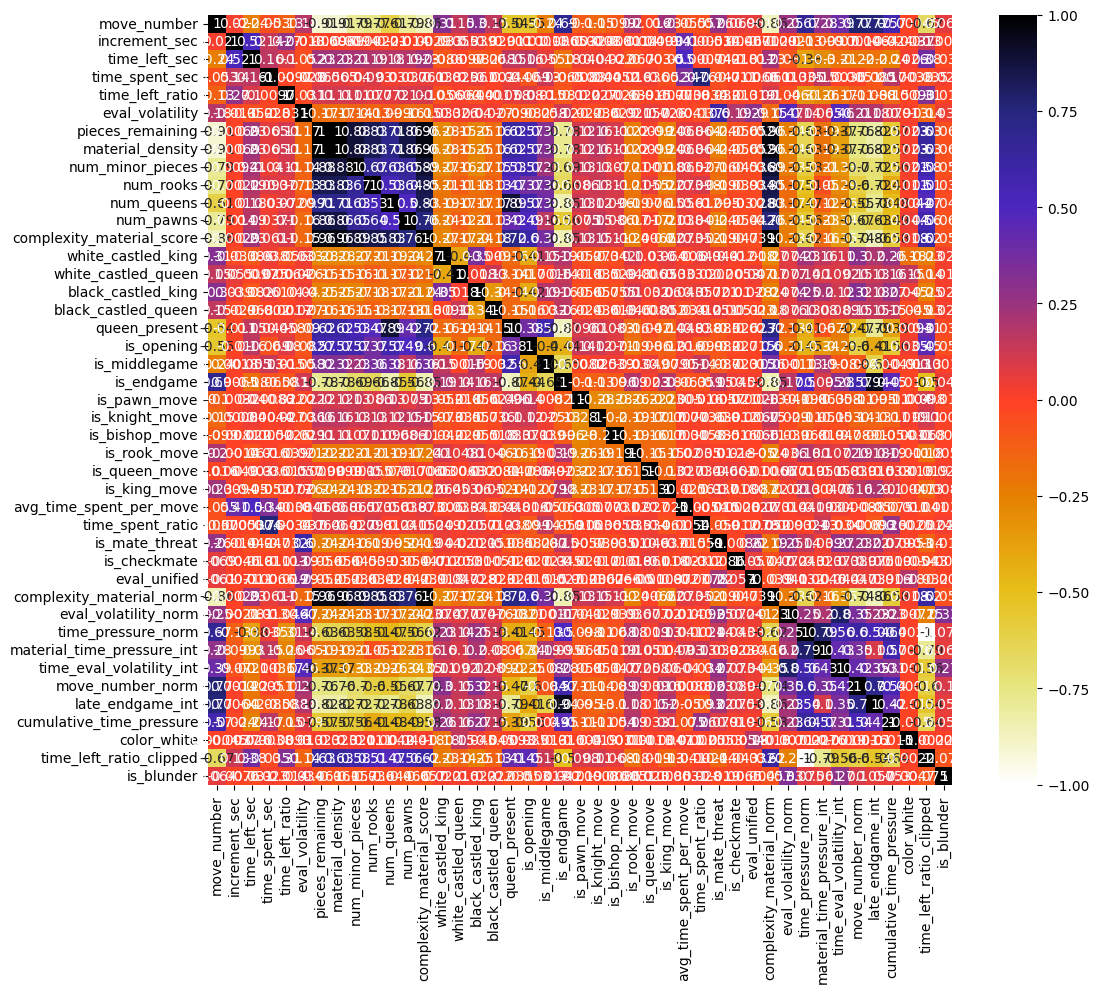

In [79]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = train_df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [80]:
train_df.corr()

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,...,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white,time_left_ratio_clipped,is_blunder
move_number,1.000000,0.019579,-0.236638,-0.053203,-0.129683,0.176960,-0.913249,-0.913249,-0.789730,-0.772802,...,0.251287,0.669779,0.277720,0.392342,0.772357,0.765124,0.567267,-0.000449,-0.669779,0.063864
increment_sec,0.019579,1.000000,0.519934,0.144894,0.269408,-0.012879,-0.006861,-0.006861,0.009355,-0.002223,...,-0.002056,-0.128404,-0.098748,-0.069517,0.001356,0.006377,-0.023572,-0.003724,0.128404,-0.007575
time_left_sec,-0.236638,0.519934,1.000000,0.161206,0.099893,-0.051803,0.227125,0.227125,0.213583,0.188033,...,-0.081420,-0.375122,-0.295520,-0.210789,-0.215393,-0.199028,-0.243495,0.025610,0.375122,-0.030679
time_spent_sec,-0.053203,0.144894,0.161206,1.000000,-0.009689,-0.028324,0.065409,0.065409,0.039634,0.093434,...,0.013330,0.034827,0.153526,-0.003602,0.005068,-0.084680,0.172954,0.003820,-0.034827,0.023437
time_left_ratio,-0.129683,0.269408,0.099893,-0.009689,1.000000,-0.030505,0.111359,0.111359,0.105718,0.077081,...,-0.046336,-0.314124,-0.260357,-0.172484,-0.108226,-0.088053,-0.147400,-0.009266,0.314124,-0.014308
eval_volatility,0.176960,-0.012879,-0.051803,-0.028324,-0.030505,1.000000,-0.169709,-0.169709,-0.137119,-0.133737,...,0.472473,0.140161,0.064542,0.461836,0.207613,0.180032,0.079025,0.013110,-0.140161,0.034134
pieces_remaining,-0.913249,-0.006861,0.227125,0.065409,0.111359,-0.169709,1.000000,1.000000,0.884497,0.833966,...,-0.244221,-0.634181,-0.188633,-0.367692,-0.757472,-0.824422,-0.566872,0.022990,0.634181,-0.060969
material_density,-0.913249,-0.006861,0.227125,0.065409,0.111359,-0.169709,1.000000,1.000000,0.884497,0.833966,...,-0.244221,-0.634181,-0.188633,-0.367692,-0.757472,-0.824422,-0.566872,0.022990,0.634181,-0.060969
num_minor_pieces,-0.789730,0.009355,0.213583,0.039634,0.105718,-0.137119,0.884497,0.884497,1.000000,0.666730,...,-0.226597,-0.579325,-0.205963,-0.327085,-0.696313,-0.716949,-0.563579,0.021385,0.579325,-0.056803
num_rooks,-0.772802,-0.002223,0.188033,0.093434,0.077081,-0.133737,0.833966,0.833966,0.666730,1.000000,...,-0.167485,-0.510054,-0.049744,-0.287228,-0.600982,-0.721534,-0.414690,0.010793,0.510054,-0.036095


In [81]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in the absolute coefficient value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [82]:
corr_features = correlation(train_df, 0.8)
len(set(corr_features))

11

In [83]:
corr_features

{'complexity_material_norm',
 'complexity_material_score',
 'is_endgame',
 'late_endgame_int',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_rooks',
 'pieces_remaining',
 'queen_present',
 'time_left_ratio_clipped'}

Decide which columns to drop

In [84]:
X_train = X_train.drop([
'move_number',
'eval_volatility',
 'complexity_material_score',
 'time_left_ratio',
 'is_opening',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_queens',
 'num_rooks',
 'pieces_remaining'], axis=1)

In [85]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'time_spent_sec',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'eval_unified',
       'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [86]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train, random_state=42)
mutual_info

array([0.00099124, 0.00226571, 0.00151298, 0.00944854, 0.00163218,
       0.00971014, 0.00054826, 0.01087426, 0.00479699, 0.00678971,
       0.00254988, 0.00071994, 0.00123959, 0.00052425, 0.        ,
       0.        , 0.00186704, 0.00202116, 0.00078456, 0.00018307,
       0.00745705, 0.00337624, 0.03490675, 0.0017088 , 0.00240971,
       0.01948234, 0.00605578, 0.00135456, 0.00433595, 0.00720721,
       0.00287102])

In [87]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

eval_volatility_norm          0.034907
time_eval_volatility_int      0.019482
queen_present                 0.010874
black_castled_king            0.009710
white_castled_king            0.009449
eval_unified                  0.007457
color_white                   0.007207
is_endgame                    0.006790
move_number_norm              0.006056
is_middlegame                 0.004797
cumulative_time_pressure      0.004336
complexity_material_norm      0.003376
time_left_ratio_clipped       0.002871
is_pawn_move                  0.002550
material_time_pressure_int    0.002410
time_left_sec                 0.002266
time_spent_ratio              0.002021
avg_time_spent_per_move       0.001867
time_pressure_norm            0.001709
white_castled_queen           0.001632
time_spent_sec                0.001513
late_endgame_int              0.001355
is_bishop_move                0.001240
increment_sec                 0.000991
is_mate_threat                0.000785
is_knight_move           

In [88]:

# Get column names where mutual info is less than 0
low_mi_columns = mutual_info[mutual_info <= 0].index.tolist()

print(low_mi_columns)

['is_queen_move', 'is_king_move']


In [89]:
X_train = X_train.drop(low_mi_columns, axis=1)

In [90]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [91]:
X_train.shape

(57019, 29)

In [92]:
X_test.shape

(14255, 29)

In [93]:
train_df = pd.concat([X_train, y_train], axis=1)

After splitting — run VIF (Variance Inflation Factor) on the training set only.

* VIF measures how much the variance of a coefficient is inflated due to multicollinearity with other features.

* Formula: VIF_i = 1 / (1 - Rscore_i)
* where Rscore_i is the coefficient of determination from regressing feature i on all other features.

* Interpretation:
 - VIF = 1: No correlation with other features
 - VIF = 5: Rscore = 0.80 (feature is 80% predictable from others)
 - VIF = 10: Rscore = 0.90 (feature is 90% predictable from others)

In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF ANALYSIS

def calculate_vif(df, features):
    vif_data = []
    
    # Remove rows with any NaN in the features
    df_clean = df[features].dropna()
    
    if len(df_clean) < 2:
        print("Not enough data for VIF calculation")
        return pd.DataFrame()
    
    print(f"\nCalculating VIF for {len(features)} features")
    print(f"Using {len(df_clean)} complete cases")
    
    for i, feature in enumerate(features):
        try:
            vif = variance_inflation_factor(df_clean.values, i)
            vif_data.append({
                'Feature': feature,
                'VIF': vif,
                'Status': 'SEVERE (>10)' if vif > 10 else 'MODERATE (5-10)' if vif > 5 else 'OK (<5)'
            })
        except Exception as e:
            vif_data.append({
                'Feature': feature,
                'VIF': np.nan,
                'Status': 'ERROR'
            })
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Calculate VIF for all continuous features
print("\n VIF for All Features")
vif_all = calculate_vif(X_train, X_train.columns)

if len(vif_all) > 0:
    print("\n", vif_all.to_string(index=False))
    
    # Identify problematic features
    severe_vif = vif_all[vif_all['VIF'] > 10]
    moderate_vif = vif_all[(vif_all['VIF'] >= 5) & (vif_all['VIF'] <= 10)]
    
    print(f"\n VIF Summary:")
    print(f"SEVERE (VIF > 10): {len(severe_vif)} features")
    print(f"MODERATE (VIF 5-10): {len(moderate_vif)} features")
    print(f"OK (VIF < 5): {len(vif_all) - len(severe_vif) - len(moderate_vif)} features")
    
else:
    print("Could not calculate VIF")



 VIF for All Features

Calculating VIF for 29 features
Using 57019 complete cases

                    Feature       VIF          Status
   time_left_ratio_clipped 99.299484    SEVERE (>10)
        time_pressure_norm 33.443662    SEVERE (>10)
                is_endgame 19.953315    SEVERE (>10)
          late_endgame_int 17.349530    SEVERE (>10)
  complexity_material_norm 10.547924    SEVERE (>10)
material_time_pressure_int  7.515360 MODERATE (5-10)
  time_eval_volatility_int  4.989008         OK (<5)
          move_number_norm  4.394563         OK (<5)
             queen_present  4.102898         OK (<5)
             is_middlegame  3.793009         OK (<5)
      eval_volatility_norm  3.772572         OK (<5)
            time_spent_sec  3.267651         OK (<5)
          time_spent_ratio  3.092039         OK (<5)
  cumulative_time_pressure  2.884958         OK (<5)
             time_left_sec  1.980322         OK (<5)
   avg_time_spent_per_move  1.952886         OK (<5)
        white_

In [95]:
# remove the columns determined
cols_to_drop = ['is_endgame' ]

In [96]:
X_train = X_train.drop(cols_to_drop, axis=1)

In [97]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [98]:
X_train.shape

(57019, 28)

In [99]:
X_test.shape

(14255, 28)

In [100]:
train_df = pd.concat([X_train, y_train], axis=1)

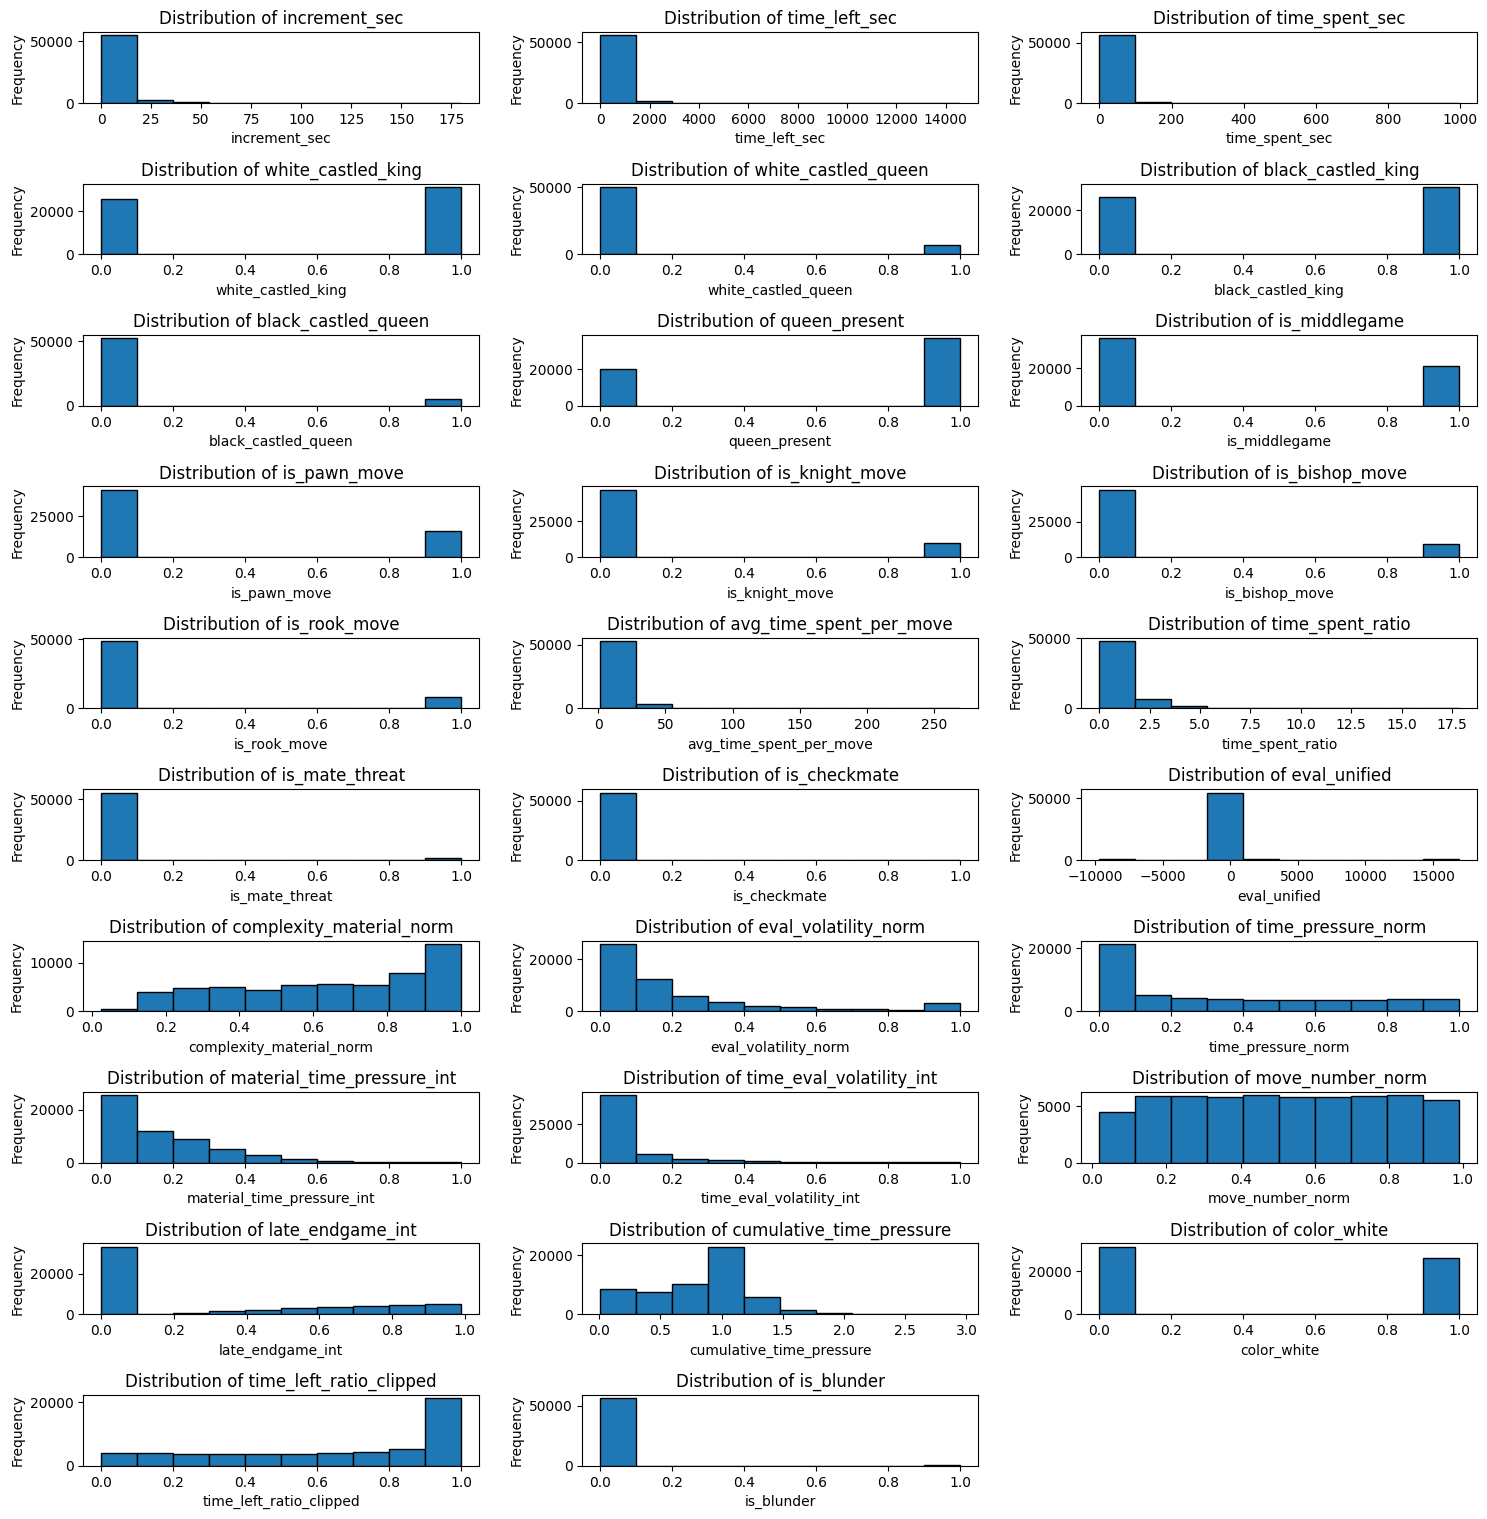

In [101]:
columns_df = train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Determine scaling methods

In [102]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'time_spent_sec',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_middlegame', 'is_pawn_move',
       'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'avg_time_spent_per_move', 'time_spent_ratio', 'is_mate_threat',
       'is_checkmate', 'eval_unified', 'complexity_material_norm',
       'eval_volatility_norm', 'time_pressure_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'late_endgame_int', 'cumulative_time_pressure',
       'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [103]:
scale_only_features = [
    'complexity_material_norm',   # roughly uniform — mild scaling benefit
    'eval_volatility_norm',       # right-skewed zero-inflated
    'time_pressure_norm',         # right-skewed
    'material_time_pressure_int', # right-skewed zero-inflated
    'time_eval_volatility_int',   # heavily zero-inflated
    'late_endgame_int',           # heavily zero-inflated
    'move_number_norm',           # roughly uniform — mild scaling benefit
    'time_left_ratio_clipped',    # left-skewed (most values near 1)
]

In [104]:
from sklearn.preprocessing import StandardScaler
import numpy as np

log_cols = [
    'increment_sec', 'time_left_sec', 'time_spent_sec',
    'avg_time_spent_per_move', 'time_spent_ratio', 'cumulative_time_pressure'
]
for col in log_cols:
    cap = X_train[col].quantile(0.95)
    X_train[col] = np.log1p(X_train[col].clip(0, cap))
    X_test[col]  = np.log1p(X_test[col].clip(0, cap))

for col in ['eval_unified']:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)

scale_cols = log_cols + ['eval_unified'] + scale_only_features

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

In [105]:
scaled_train_df = pd.concat([X_train, y_train], axis=1)

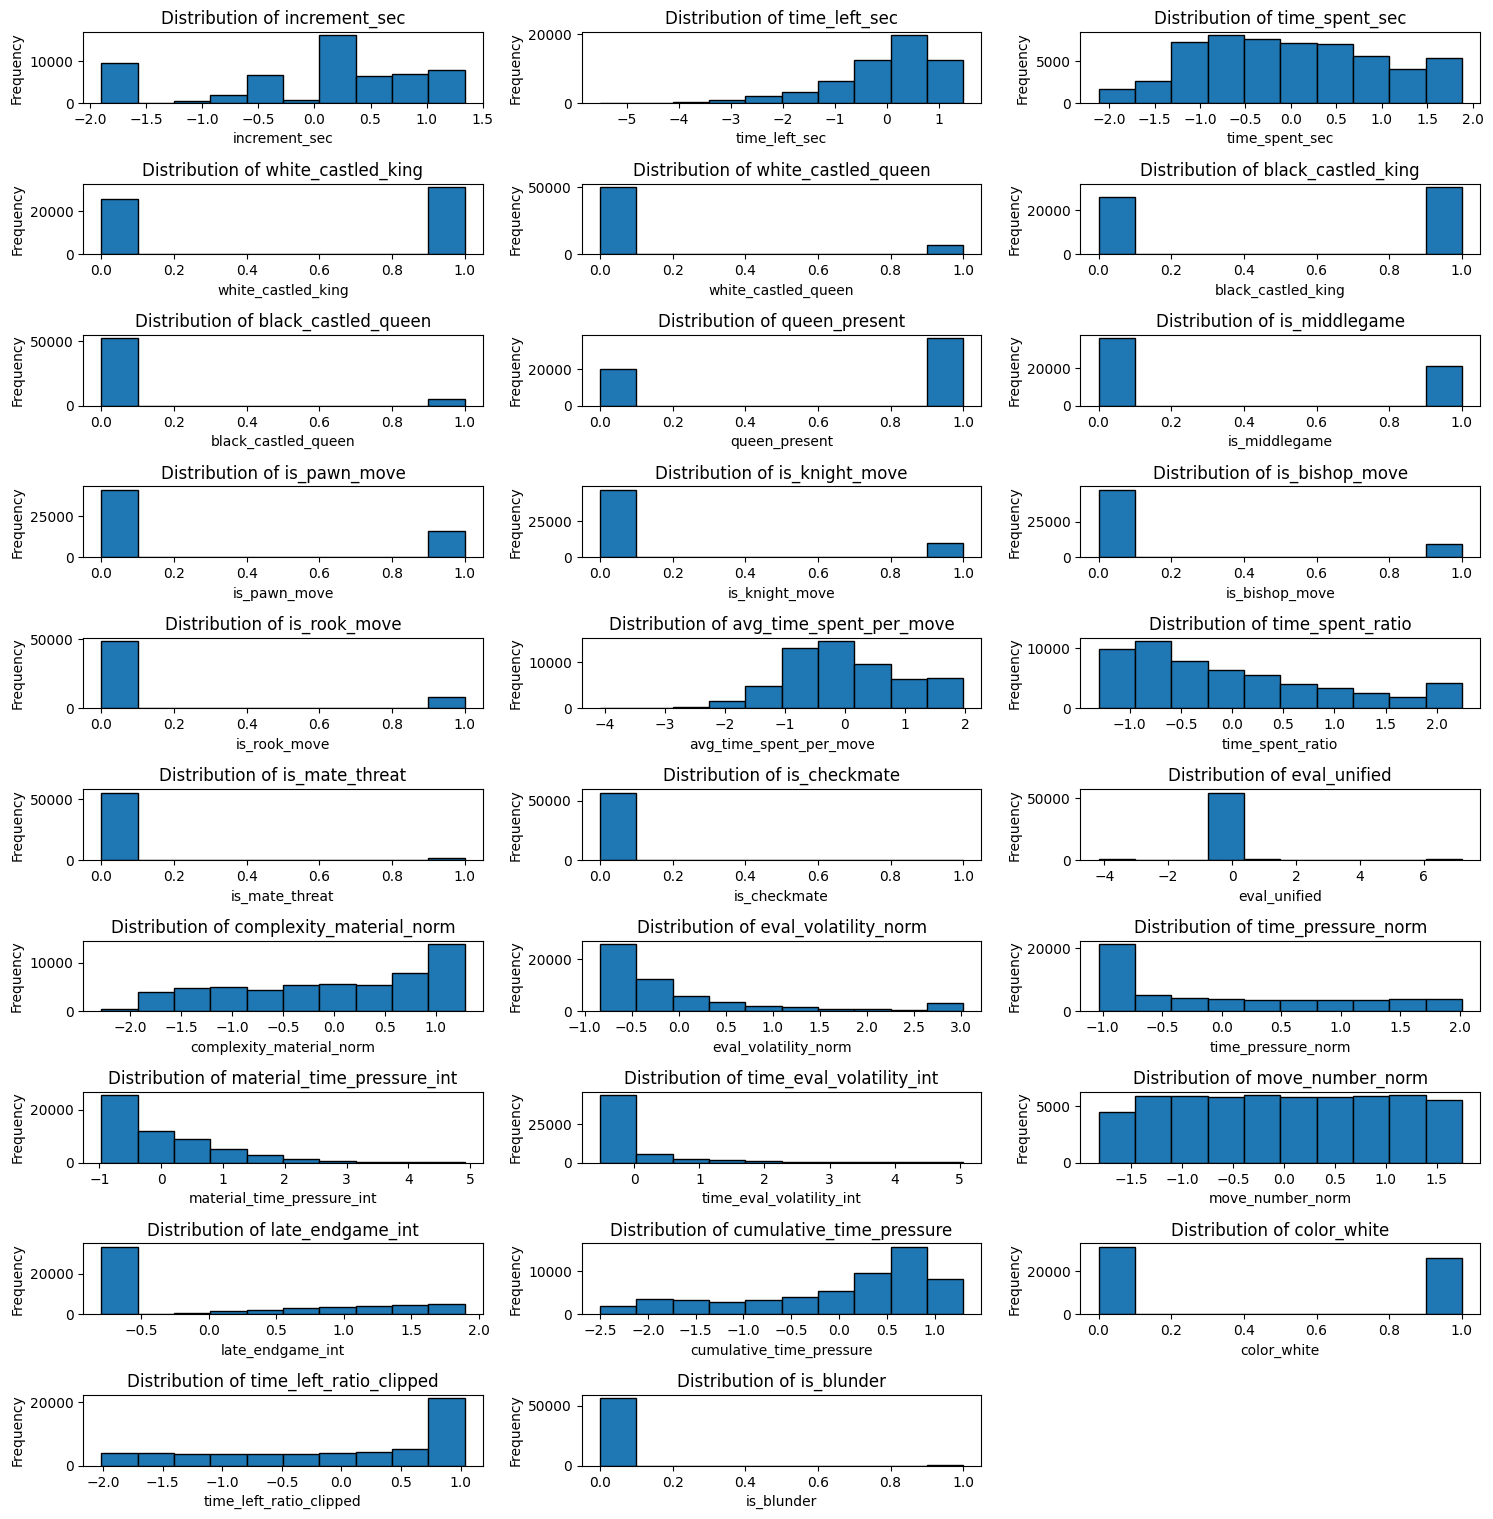

In [106]:
columns_df = scaled_train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(scaled_train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [107]:
X_train.to_csv('model_data/scaled_blunder_standard_X_train.csv', index=False)
X_test.to_csv('model_data/scaled_blunder_standard_X_test.csv', index=False)

In [108]:
y_train.to_csv('model_data/blunder_standard_y_train.csv', index=False)
y_test.to_csv('model_data/blunder_standard_y_test.csv', index=False)